In [1]:
import sys
import tensorflow as tf

print(f"TensorFlow ver is {tf.__version__}")
print(f"PYTHON ver is {sys.version}")
print("GPU is","available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TensorFlow ver is 2.10.0
PYTHON ver is 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
GPU is available


# CELL 1) IMPORT + 기본 설정

In [2]:
# %%
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("GPU:", "available" if tf.config.list_physical_devices("GPU") else "NOT AVAILABLE")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


TF: 2.10.0
GPU: available


# CELL 2) PATH / HYPERPARAMETER / SPEC

In [9]:
# %%
DATA_DIR  = "database"
EVAL_FILE = "small_cases.csv"   # 7 rows

# residue stack
QUALITY_RES_PATH  = "best_model_residue.h5"
POLICY_RES_PATH   = "policy_residue.keras"
SCALER_X_RES_PATH = "scaler_x_res_38.pkl"
SCALER_Y_RES_PATH = "scaler_y_res_1.pkl"

# blaine stack
QUALITY_BLA_PATH  = "best_model_blaine.h5"
POLICY_BLA_PATH   = "policy_blaine.keras"
SCALER_X_BLA_PATH = "scaler_x_bla_38.pkl"
SCALER_Y_BLA_PATH = "scaler_y_bla_1.pkl"

# simulation knobs
N_STEPS = 30
ROW_IDX = 0            # 0~6 중 선택
DELTA_MAX_DEFAULT = 0.2

# specs
RES_MIN, RES_MAX = 7.0, 9.0
BLA_MIN, BLA_MAX = 3700.0, 3900.0


# CELL 3) COLUMN 정의 (학습과 동일해야 함)

In [4]:
# %%
CONTROL_COLS_9 = [
    "RP_roller_p1","RP_roller_p2","RP_sep_rpm","RP_sep_fan_damper","RP_sep_BF_damper",
    "mill_BF_damper","mill_sep_rpm","mill_sep_fan_damper","grind_aid",
]
MONITOR_COLS_28 = [
    "RP_spac","RP_skew","RP_roller_energy1","RP_roller_energy2","RP_roller_vib",
    "RP_BE_energy1","RP_BE_energy2","RP_sep_BF_pressure","dosing_BE_energy","mill_feed_c",
    "mill_feed_cir","mill_energy","mill_in_temp","mill_out_temp","mill_BE_energy",
    "mill_out_gas_temp","mill_out_mater_temp","mill_BF_pressure","mill_sep_BF_pressure",
    "mill_sep_fan_damper","final_BE_1","final_BE_2","final_mater_temp",
    "feed_clinker","feed_gypsum","feed_slag","feed_FA","feed_total",
]
assert len(CONTROL_COLS_9) == 9
assert len(MONITOR_COLS_28) == 28

# small_cases.csv에 반드시 존재해야 하는 품질 컬럼(1번 방식)
RES_COL   = "residue"
RES_T_COL = "residue_target"
BLA_COL   = "blaine"
BLA_T_COL = "blaine_target"

POLICY_INPUT_DIM = 28 + 1 + 9 + 1  # 39


# CELL 4) SMALL_CASES 로드 + 모델/스케일러 로드

In [30]:
# %%
csv_path = os.path.join(DATA_DIR, EVAL_FILE)
df_cases = pd.read_csv(csv_path)

required_cols = CONTROL_COLS_9 + MONITOR_COLS_28 + [RES_COL, RES_T_COL, BLA_COL, BLA_T_COL]
missing = [c for c in required_cols if c not in df_cases.columns]
if missing:
    raise ValueError(f"small_cases.csv missing required columns: {missing}")

df_cases = df_cases.dropna(subset=required_cols).reset_index(drop=True)
print("Cases shape:", df_cases.shape)
display(df_cases)

# load scalers/models
scaler_x_res = joblib.load(SCALER_X_RES_PATH)
scaler_y_res = joblib.load(SCALER_Y_RES_PATH)
quality_res  = tf.keras.models.load_model(QUALITY_RES_PATH); quality_res.trainable = False
policy_res   = tf.keras.models.load_model(POLICY_RES_PATH);  policy_res.trainable  = False

scaler_x_bla = joblib.load(SCALER_X_BLA_PATH)
scaler_y_bla = joblib.load(SCALER_Y_BLA_PATH)
quality_bla  = tf.keras.models.load_model(QUALITY_BLA_PATH); quality_bla.trainable = False
policy_bla   = tf.keras.models.load_model(POLICY_BLA_PATH);  policy_bla.trainable  = False

print("Loaded OK")
print("quality_res in/out:", quality_res.input_shape, quality_res.output_shape)
print("quality_bla in/out:", quality_bla.input_shape, quality_bla.output_shape)
print("policy_res out:", policy_res.output_shape)
print("policy_bla out:", policy_bla.output_shape)


Cases shape: (14, 43)


,RP_roller_p1,RP_roller_p2,RP_sep_rpm,RP_sep_fan_damper,RP_sep_BF_damper,mill_BF_damper,mill_sep_rpm,mill_sep_fan_damper,grind_aid,RP_spac,RP_skew,RP_roller_energy1,RP_roller_energy2,RP_roller_vib,RP_BE_energy1,RP_BE_energy2,RP_sep_BF_pressure,dosing_BE_energy,mill_feed_c,mill_feed_cir,mill_energy,mill_in_temp,mill_out_temp,mill_BE_energy,mill_out_gas_temp,mill_out_mater_temp,mill_BF_pressure,mill_sep_BF_pressure,mill_sep_BF_fan_damper,final_BE_1,final_BE_2,final_mater_temp,feed_total,feed_clinker,feed_gypsum,feed_slag,feed_FA,blaine,residue,blaine_prev,residue_prev,blaine_target,residue_target
0,74,73,463,100,60,25,1112,100,149.4,46,1,147,144,1.0,0,124,-103,22,364,576,163,50,58,68,109,115,-149,-283,30,88,77,95,223.2,189.6,11.3,11.1,11.2,3550,8.9,3720,8.7,3800,8
1,73,77,390,100,60,15,1165,100,151.2,43,0,145,133,1.5,0,124,-84,20,338,546,172,34,43,71,95,101,-132,-236,30,90,78,78,221.1,190.1,11.2,11.0,8.8,3700,7.8,3860,8.5,3800,8
2,68,77,445,100,60,15,1156,100,151.2,49,0,148,141,1.3,0,125,-68,19,389,613,161,46,54,71,99,105,-115,-224,30,90,78,88,217.2,186.7,11.0,10.8,8.7,3780,8.2,3590,8.5,3800,8
3,78,79,462,100,60,15,1146,100,158.4,48,0,159,151,1.1,0,121,-72,20,398,613,168,45,53,74,101,108,-121,-219,30,72,61,89,220.2,186.3,10.7,11.0,12.2,3570,8.6,3680,8.3,3800,8
4,74,76,446,100,60,20,1139,100,199.8,42,7,153,146,1.2,0,124,-86,20,360,571,168,49,56,70,110,116,-128,-268,30,85,77,95,217.9,184.8,11.3,10.9,10.9,3610,8.7,3590,8.6,3800,8
5,78,77,454,100,60,20,1145,100,210.6,48,0,149,147,1.2,0,124,-79,20,365,574,169,51,56,68,113,119,-137,-258,30,66,61,98,219.4,184.8,11.6,10.9,12.1,3840,8.5,3720,8.4,3800,8
6,81,83,404,100,60,20,1119,100,210.6,45,1,149,142,1.0,0,122,-84,20,384,587,166,57,61,72,112,117,-141,-270,30,87,77,96,217.8,183.9,11.5,10.9,11.5,3780,8.7,3780,9.0,3800,8
7,81,83,472,100,60,25,1102,100,149.4,43,1,154,147,1.2,0,122,-77,20,413,626,168,56,59,77,115,121,-155,-275,45,87,75,100,220.8,186.0,12.6,11.0,11.2,3800,9.0,3820,8.1,3800,8
8,76,85,467,100,40,30,1037,100,156.1,35,1,141,122,0.6,79,80,-167,20,336,569,163,37,44,64,106,111,-159,-290,40,80,73,101,207.4,178.3,12.4,10.4,6.3,3770,4.5,3790,4.7,3800,8
9,75,78,445,100,60,20,1145,100,210.6,46,1,152,150,1.4,0,122,-87,22,408,625,169,47,51,70,108,114,-146,-271,30,84,75,94,220.3,185.5,11.6,11.0,12.2,3550,9.3,3590,8.5,3800,8


Loaded OK
quality_res in/out: (None, 38) (None, 1)
quality_bla in/out: (None, 38) (None, 1)
policy_res out: (None, 9)
policy_bla out: (None, 9)


# CELL 5) HELPER 함수들 (정규화/정책/품질예측)

In [11]:
# %%
def split_norm_from_scaler_x(u_raw_1x9, mon_raw_1x28, qprev_raw_1x1, scaler_x):
    Xq_raw  = np.concatenate([u_raw_1x9, mon_raw_1x28, qprev_raw_1x1], axis=1).astype(np.float32)  # (1,38)
    Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)
    u_norm    = Xq_norm[:, :9]
    mon_norm  = Xq_norm[:, 9:9+28]
    qprev_norm = Xq_norm[:, 9+28:9+28+1]
    return u_norm, mon_norm, qprev_norm, Xq_norm


def policy_delta_norm(policy_net, mon_norm, qcur_norm, u_cur_norm, yT_norm, delta_max_default):
    Xp_39 = np.concatenate([mon_norm, qcur_norm, u_cur_norm, yT_norm], axis=1).astype(np.float32)  # (1,39)
    assert Xp_39.shape[1] == POLICY_INPUT_DIM
    delta_raw = policy_net(Xp_39, training=False).numpy().astype(np.float32)  # (1,9) in [-1,1]
    DELTA_MAX = np.array([delta_max_default]*9, dtype=np.float32).reshape(1, -1)
    delta_norm = delta_raw * DELTA_MAX
    return delta_norm, delta_raw


def quality_forward_norm(quality_model, u_new_norm, mon_norm, qprev_norm):
    Xq_new = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (1,38)
    y_norm = quality_model(Xq_new, training=False).numpy().astype(np.float32)               # (1,1)
    return y_norm, Xq_new


# CELL 6) 가변 alpha 규칙 (residue 우선 예시)

In [12]:
# %%
def alpha_rule_res_first(res_before, bla_before,
                         res_min=RES_MIN, res_max=RES_MAX,
                         alpha_when_res_out=0.1,
                         alpha_when_res_in=0.7):
    res_in = (res_min <= res_before <= res_max)
    return float(alpha_when_res_in if res_in else alpha_when_res_out)


# CELL 7) 폐루프 시뮬레이터

In [13]:
# %%
def simulate_closed_loop_2quality_case_row(
    case_row: pd.Series,
    n_steps: int,
    alpha_rule,
    policy_res, quality_res, scaler_x_res, scaler_y_res,
    policy_bla, quality_bla, scaler_x_bla, scaler_y_bla,
    delta_max_default: float = 0.02,
):
    # --- initial raw controls/monitors
    u_raw   = case_row[CONTROL_COLS_9].to_numpy(np.float32).reshape(1, -1)    # (1,9)
    mon_raw = case_row[MONITOR_COLS_28].to_numpy(np.float32).reshape(1, -1)   # (1,28)

    # --- initial quality & targets (CSV 값을 그대로 사용: 1번 방식)
    res_qcur  = np.array([[float(case_row[RES_COL])]], np.float32)
    bla_qcur  = np.array([[float(case_row[BLA_COL])]], np.float32)
    yT_res    = np.array([[float(case_row[RES_T_COL])]], np.float32)
    yT_bla    = np.array([[float(case_row[BLA_T_COL])]], np.float32)

    # --- 초기 qprev는 CSV에 별도값이 없으니 qcur로 시작(가장 일반적인 폐루프 초기화)
    res_qprev = res_qcur.copy()
    bla_qprev = bla_qcur.copy()

    logs = []

    for k in range(n_steps):
        # (0) alpha (blaine weight)
        a = float(alpha_rule(float(res_qcur[0,0]), float(bla_qcur[0,0])))
        a = float(np.clip(a, 0.0, 1.0))

        # (1) residue policy delta
        u_norm_res, mon_norm_res, qprev_norm_res, _ = split_norm_from_scaler_x(u_raw, mon_raw, res_qprev, scaler_x_res)
        qcur_norm_res = scaler_y_res.transform(res_qcur).astype(np.float32)
        yT_norm_res   = scaler_y_res.transform(yT_res).astype(np.float32)
        delta_res_norm, _ = policy_delta_norm(policy_res, mon_norm_res, qcur_norm_res, u_norm_res, yT_norm_res, delta_max_default)

        # (2) blaine policy delta
        u_norm_bla, mon_norm_bla, qprev_norm_bla, _ = split_norm_from_scaler_x(u_raw, mon_raw, bla_qprev, scaler_x_bla)
        qcur_norm_bla = scaler_y_bla.transform(bla_qcur).astype(np.float32)
        yT_norm_bla   = scaler_y_bla.transform(yT_bla).astype(np.float32)
        delta_bla_norm, _ = policy_delta_norm(policy_bla, mon_norm_bla, qcur_norm_bla, u_norm_bla, yT_norm_bla, delta_max_default)

        # (3) mix delta in normalized control space
        delta_mix_norm = (1.0 - a) * delta_res_norm + a * delta_bla_norm

        # (4) apply (use residue u_norm as reference) + clip
        u_new_norm_res = np.clip(u_norm_res + delta_mix_norm, 0.0, 1.0)

        # (5) recover u_new_raw (controls) via scaler_x_res inverse
        Xq_new_res_norm = np.concatenate([u_new_norm_res, mon_norm_res, qprev_norm_res], axis=1).astype(np.float32)  # (1,38)
        Xq_new_res_raw  = scaler_x_res.inverse_transform(Xq_new_res_norm).astype(np.float32)
        u_new_raw = Xq_new_res_raw[:, :9]

        # (6) residue next
        res_next_norm, _ = quality_forward_norm(quality_res, u_new_norm_res, mon_norm_res, qprev_norm_res)
        res_next = scaler_y_res.inverse_transform(res_next_norm).astype(np.float32)

        # (7) blaine next (rebuild norm in blaine scaler_x space using u_new_raw + bla_qprev)
        u_new_norm_bla, mon_norm_bla2, qprev_norm_bla2, _ = split_norm_from_scaler_x(u_new_raw, mon_raw, bla_qprev, scaler_x_bla)
        bla_next_norm, _ = quality_forward_norm(quality_bla, u_new_norm_bla, mon_norm_bla2, qprev_norm_bla2)
        bla_next = scaler_y_bla.inverse_transform(bla_next_norm).astype(np.float32)

        # (8) log
        row = {
            "step": k,
            "alpha(bla_weight)": a,

            "res_qprev": float(res_qprev[0,0]),
            "res_qcur":  float(res_qcur[0,0]),
            "res_next":  float(res_next[0,0]),
            "res_target": float(yT_res[0,0]),
            "res_in_spec(cur)": float(RES_MIN <= res_qcur[0,0] <= RES_MAX),
            "res_in_spec(next)": float(RES_MIN <= res_next[0,0] <= RES_MAX),

            "bla_qprev": float(bla_qprev[0,0]),
            "bla_qcur":  float(bla_qcur[0,0]),
            "bla_next":  float(bla_next[0,0]),
            "bla_target": float(yT_bla[0,0]),
            "bla_in_spec(cur)": float(BLA_MIN <= bla_qcur[0,0] <= BLA_MAX),
            "bla_in_spec(next)": float(BLA_MIN <= bla_next[0,0] <= BLA_MAX),

            "spec_both(cur)": float((RES_MIN <= res_qcur[0,0] <= RES_MAX) and (BLA_MIN <= bla_qcur[0,0] <= BLA_MAX)),
            "spec_both(next)": float((RES_MIN <= res_next[0,0] <= RES_MAX) and (BLA_MIN <= bla_next[0,0] <= BLA_MAX)),

            "sum_abs_delta_u(raw)": float(np.sum(np.abs(u_new_raw - u_raw))),
        }

        for i, c in enumerate(CONTROL_COLS_9):
            row[f"{c}_cur"]   = float(u_raw[0,i])
            row[f"{c}_new"]   = float(u_new_raw[0,i])
            row[f"{c}_delta"] = float(u_new_raw[0,i] - u_raw[0,i])

        logs.append(row)

        # (9) update state
        res_qprev = res_qcur.copy()
        bla_qprev = bla_qcur.copy()
        res_qcur  = res_next.copy()
        bla_qcur  = bla_next.copy()
        u_raw     = u_new_raw.copy()

    return pd.DataFrame(logs)


# CELL 8) 실행 (ROW_IDX의 1개 케이스로 30 step)

In [33]:
# %%
ROW_IDX = 0            # 0~6 중 선택
DELTA_MAX_DEFAULT = 0.02

case_row = df_cases.iloc[ROW_IDX]

sim_df = simulate_closed_loop_2quality_case_row(
    case_row=case_row,
    n_steps=N_STEPS,
    alpha_rule=alpha_rule_res_first,
    policy_res=policy_res, quality_res=quality_res, scaler_x_res=scaler_x_res, scaler_y_res=scaler_y_res,
    policy_bla=policy_bla, quality_bla=quality_bla, scaler_x_bla=scaler_x_bla, scaler_y_bla=scaler_y_bla,
    delta_max_default=DELTA_MAX_DEFAULT,
)

# display(sim_df.head(10))
# display(sim_df.tail(10))


# CELL 9) 수렴 그래프 (RESIDUE / BLAINE)

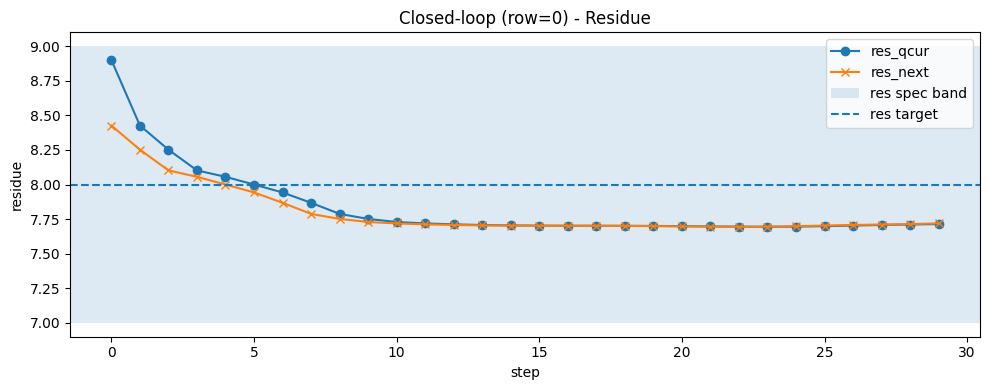

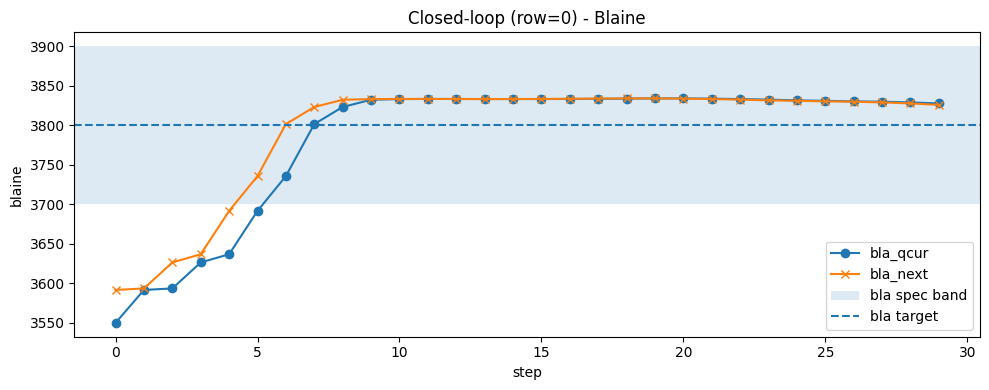

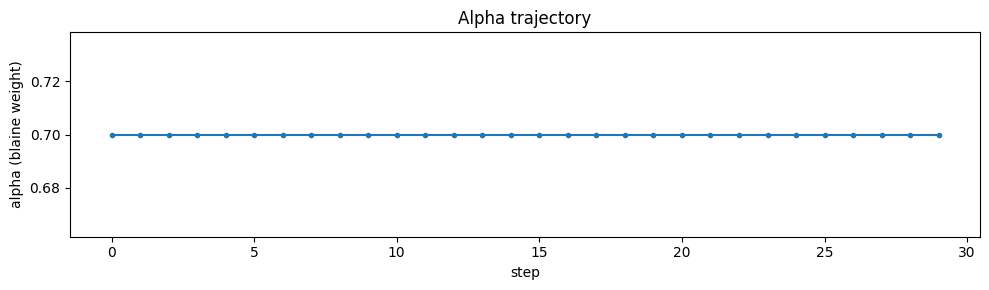

In [34]:
# %%
plt.figure(figsize=(10,4))
plt.plot(sim_df["step"], sim_df["res_qcur"], marker="o", label="res_qcur")
plt.plot(sim_df["step"], sim_df["res_next"], marker="x", label="res_next")
plt.axhspan(RES_MIN, RES_MAX, alpha=0.15, label="res spec band")
plt.axhline(sim_df["res_target"].iloc[0], linestyle="--", label="res target")
plt.xlabel("step"); plt.ylabel("residue")
plt.title(f"Closed-loop (row={ROW_IDX}) - Residue")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(sim_df["step"], sim_df["bla_qcur"], marker="o", label="bla_qcur")
plt.plot(sim_df["step"], sim_df["bla_next"], marker="x", label="bla_next")
plt.axhspan(BLA_MIN, BLA_MAX, alpha=0.15, label="bla spec band")
plt.axhline(sim_df["bla_target"].iloc[0], linestyle="--", label="bla target")
plt.xlabel("step"); plt.ylabel("blaine")
plt.title(f"Closed-loop (row={ROW_IDX}) - Blaine")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,3))
plt.plot(sim_df["step"], sim_df["alpha(bla_weight)"], marker=".")
plt.xlabel("step"); plt.ylabel("alpha (blaine weight)")
plt.title("Alpha trajectory")
plt.tight_layout(); plt.show()


# CELL 10) 요약 리포트 (30 STEP 동안 SPEC 만족률/개선 정도)

In [16]:
# %%
summary = pd.DataFrame([{
    "row_idx": ROW_IDX,
    "steps": N_STEPS,
    "res_spec_in_rate_next(%)": sim_df["res_in_spec(next)"].mean() * 100,
    "bla_spec_in_rate_next(%)": sim_df["bla_in_spec(next)"].mean() * 100,
    "both_spec_in_rate_next(%)": sim_df["spec_both(next)"].mean() * 100,
    "mean_sum_abs_delta_u(raw)": sim_df["sum_abs_delta_u(raw)"].mean(),
    "final_res": sim_df["res_next"].iloc[-1],
    "final_bla": sim_df["bla_next"].iloc[-1],
    "final_alpha": sim_df["alpha(bla_weight)"].iloc[-1],
}])

display(summary)


,row_idx,steps,res_spec_in_rate_next(%),bla_spec_in_rate_next(%),both_spec_in_rate_next(%),mean_sum_abs_delta_u(raw),final_res,final_bla,final_alpha
0,0,30,100.0,96.666667,96.666667,72.542849,8.63935,3761.912842,0.7
